In [1]:
# Import pandas for data handling
import pandas as pd
# Import KMeans from sklearn
from sklearn.cluster import KMeans
# Import matplotlib for creating charts
import matplotlib.pyplot as plt
# Print a message to confirm all libraries are loaded
print("All libraries loaded successfully!")
print("You are ready to start the lab.")


All libraries loaded successfully!
You are ready to start the lab.


In [2]:
# Create order IDs from 1 to 50
order_ids = list(range(1, 51))

# Print to verify
print("Order IDs created:")
print(order_ids)
# Create purchase amounts
# These represent different spending levels
amounts = [
    100, 200, 150, 400, 350,   # Orders 1-5
    100, 200, 150, 400, 350,   # Orders 6-10
    100, 200, 150, 400, 350,   # Orders 11-15
    100, 200, 150, 400, 350,   # Orders 16-20
    100, 200, 150, 400, 350,   # Orders 21-25
    100, 200, 150, 400, 350,   # Orders 26-30
    100, 200, 150, 400, 350,   # Orders 31-35
    100, 200, 150, 400, 350,   # Orders 36-40
    100, 200, 150, 400, 350,   # Orders 41-45
    100, 200, 150, 400, 350    # Orders 46-50
]

print("Purchase amounts created:")
print(amounts)
# Create product categories
# We repeat the pattern 10 times to get 50 items
categories = ['Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing'] * 10

print("Categories created:")
print(categories)
# Put all data together in a dictionary
data = {
    'OrderID': order_ids,
    'Amount': amounts,
    'Category': categories
}

print("Data dictionary created with keys:")
print(data.keys())
# Convert the dictionary to a DataFrame (table)
df = pd.DataFrame(data)

print("DataFrame created successfully!")
print(f"Shape: {df.shape[0]} rows and {df.shape[1]} columns")
# Look at the first 10 rows of our data
print("First 10 rows of the dataset:")
print("=" * 40)
df.head(10)


Order IDs created:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]
Purchase amounts created:
[100, 200, 150, 400, 350, 100, 200, 150, 400, 350, 100, 200, 150, 400, 350, 100, 200, 150, 400, 350, 100, 200, 150, 400, 350, 100, 200, 150, 400, 350, 100, 200, 150, 400, 350, 100, 200, 150, 400, 350, 100, 200, 150, 400, 350, 100, 200, 150, 400, 350]
Categories created:
['Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Home', 'Clothi

,OrderID,Amount,Category
0,1,100,Electronics
1,2,200,Clothing
2,3,150,Electronics
3,4,400,Home
4,5,350,Clothing
5,6,100,Electronics
6,7,200,Clothing
7,8,150,Electronics
8,9,400,Home
9,10,350,Clothing


In [3]:
# Count total number of orders
total_orders = len(df)

print(f"Total number of orders: {total_orders}")
# Find the smallest order amount
min_amount = df['Amount'].min()

print(f"Smallest order amount: ${min_amount}")
# Find the largest order amount
max_amount = df['Amount'].max()

print(f"Largest order amount: ${max_amount}")
# Calculate the average (mean) order amount
avg_amount = df['Amount'].mean()

print(f"Average order amount: ${avg_amount:.2f}")
# Count orders in each category
category_counts = df['Category'].value_counts()

print("Number of orders by category:")
print(category_counts)
# Get a quick summary of all numeric columns
print("Statistical summary of the data:")
df.describe()


Total number of orders: 50
Smallest order amount: $100
Largest order amount: $400
Average order amount: $240.00
Number of orders by category:
Category
Electronics    20
Clothing       20
Home           10
Name: count, dtype: int64
Statistical summary of the data:


,OrderID,Amount
count,50.00000,50.000000
mean,25.50000,240.000000
std,14.57738,116.933611
min,1.00000,100.000000
25%,13.25000,150.000000
50%,25.50000,200.000000
75%,37.75000,350.000000
max,50.00000,400.000000


In [4]:
# Select the Amount column for clustering
# We use double brackets [[]] to keep it as a DataFrame
X = df[['Amount']]

print("Feature selected for clustering: Amount")
print(f"Shape of X: {X.shape}")
# Look at the first 5 values
print("First 5 values of X:")
X.head()

Feature selected for clustering: Amount
Shape of X: (50, 1)
First 5 values of X:


,Amount
0,100
1,200
2,150
3,400
4,350


In [5]:
# Create the K-Means model
# n_clusters=3 means we want 3 groups
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

print("K-Means model created!")
print(f"Number of clusters: 3")

K-Means model created!
Number of clusters: 3


In [6]:
# Fit the model and predict clusters
cluster_labels = kmeans.fit_predict(X)

print("Model trained successfully!")
print(f"Number of labels created: {len(cluster_labels)}")
# Look at the cluster labels
# Each number (0, 1, or 2) represents a different cluster
print("Cluster labels for first 20 orders:")
print(cluster_labels[:20])
# Add cluster labels to our DataFrame
df['Cluster'] = cluster_labels

print("Cluster column added to DataFrame!")
# Look at the updated DataFrame
print("DataFrame with cluster labels:")
df.head(10)

Model trained successfully!
Number of labels created: 50
Cluster labels for first 20 orders:
[1 2 1 0 0 1 2 1 0 0 1 2 1 0 0 1 2 1 0 0]
Cluster column added to DataFrame!
DataFrame with cluster labels:


,OrderID,Amount,Category,Cluster
0,1,100,Electronics,1
1,2,200,Clothing,2
2,3,150,Electronics,1
3,4,400,Home,0
4,5,350,Clothing,0
5,6,100,Electronics,1
6,7,200,Clothing,2
7,8,150,Electronics,1
8,9,400,Home,0
9,10,350,Clothing,0


In [7]:
# Get the cluster centers
centers = kmeans.cluster_centers_

print("Cluster Centers (Average Amount in each cluster):")
print("=" * 45)
# Print each cluster center with its meaning
for i, center in enumerate(centers):
    amount = center[0]
    print(f"Cluster {i}: Average spending = ${amount:.2f}")

Cluster Centers (Average Amount in each cluster):
Cluster 0: Average spending = $375.00
Cluster 1: Average spending = $125.00
Cluster 2: Average spending = $200.00


In [8]:
# Count orders in each cluster
cluster_counts = df['Cluster'].value_counts().sort_index()

print("Number of orders in each cluster:")
print("=" * 35)
# Print the counts
for cluster, count in cluster_counts.items():
    print(f"Cluster {cluster}: {count} orders")


Number of orders in each cluster:
Cluster 0: 20 orders
Cluster 1: 20 orders
Cluster 2: 10 orders


In [9]:
# Show examples from Cluster 0
print("\n" + "=" * 50)
print("CLUSTER 0 - Sample Orders:")
print("=" * 50)

cluster_0 = df[df['Cluster'] == 0]
print(cluster_0[['OrderID', 'Amount', 'Category']].head(5).to_string(index=False))
# Show examples from Cluster 1
print("\n" + "=" * 50)
print("CLUSTER 1 - Sample Orders:")
print("=" * 50)

cluster_1 = df[df['Cluster'] == 1]
print(cluster_1[['OrderID', 'Amount', 'Category']].head(5).to_string(index=False))
# Show examples from Cluster 2
print("\n" + "=" * 50)
print("CLUSTER 2 - Sample Orders:")
print("=" * 50)

cluster_2 = df[df['Cluster'] == 2]
print(cluster_2[['OrderID', 'Amount', 'Category']].head(5).to_string(index=False))



CLUSTER 0 - Sample Orders:
 OrderID  Amount Category
       4     400     Home
       5     350 Clothing
       9     400     Home
      10     350 Clothing
      14     400     Home

CLUSTER 1 - Sample Orders:
 OrderID  Amount    Category
       1     100 Electronics
       3     150 Electronics
       6     100 Electronics
       8     150 Electronics
      11     100 Electronics

CLUSTER 2 - Sample Orders:
 OrderID  Amount Category
       2     200 Clothing
       7     200 Clothing
      12     200 Clothing
      17     200 Clothing
      22     200 Clothing


Figure created with size 10x6 inches


<Figure size 1000x600 with 0 Axes>

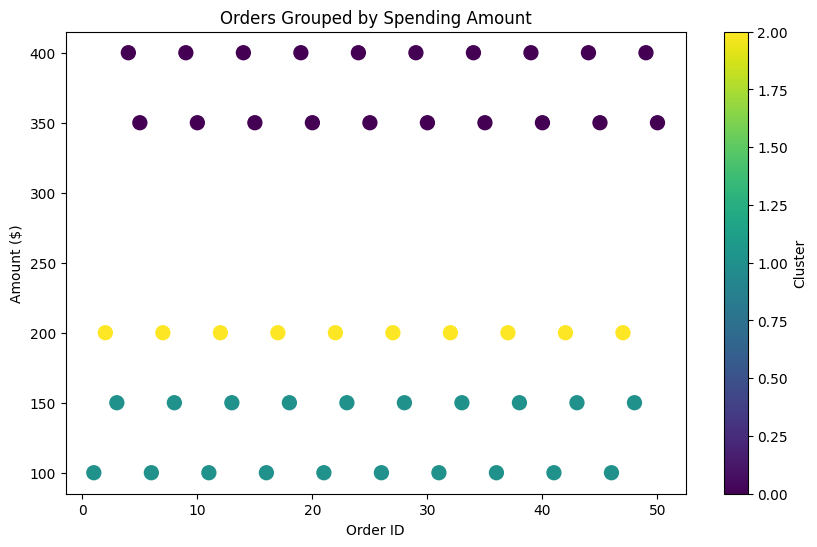

Basic scatter plot created!


In [10]:
# Create a figure (the blank canvas)
plt.figure(figsize=(10, 6))

print("Figure created with size 10x6 inches")
# Create a simple scatter plot
plt.figure(figsize=(10, 6))

# Plot all points, colored by cluster
scatter = plt.scatter(
    df['OrderID'],      # X-axis: Order ID
    df['Amount'],       # Y-axis: Amount
    c=df['Cluster'],    # Color by cluster
    cmap='viridis',     # Color scheme
    s=100               # Size of points
)

# Add labels
plt.xlabel('Order ID')
plt.ylabel('Amount ($)')
plt.title('Orders Grouped by Spending Amount')
plt.colorbar(scatter, label='Cluster')

plt.show()
print("Basic scatter plot created!")

Colors defined:
Cluster 0: Red (#FF6B6B)
Cluster 1: Teal (#4ECDC4)
Cluster 2: Blue (#45B7D1)


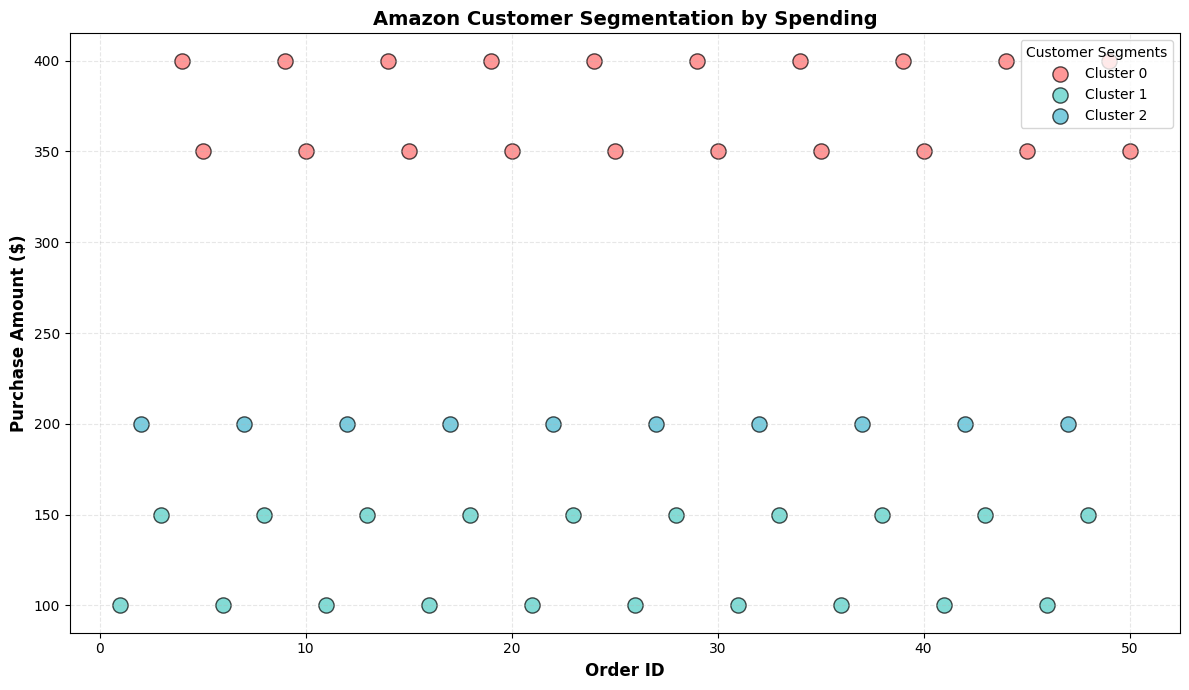

Professional chart created!


In [15]:
# Define custom colors for each cluster
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

print("Colors defined:")
print("Cluster 0: Red (#FF6B6B)")
print("Cluster 1: Teal (#4ECDC4)")
print("Cluster 2: Blue (#45B7D1)")
# Create the professional chart
plt.figure(figsize=(12, 7))

# Plot each cluster separately with custom colors
for cluster_num in sorted(df['Cluster'].unique()):
    # Get data for this cluster
    cluster_data = df[df['Cluster'] == cluster_num]

    # Plot the points
    plt.scatter(
        cluster_data['OrderID'],
        cluster_data['Amount'],
        c=colors[cluster_num],
        label=f'Cluster {cluster_num}',
        s=120,
        alpha=0.7,
        edgecolors='black',
        linewidth=1
    )

# Add labels and title
plt.xlabel('Order ID', fontsize=12, fontweight='bold')
plt.ylabel('Purchase Amount ($)', fontsize=12, fontweight='bold')
plt.title('Amazon Customer Segmentation by Spending', fontsize=14, fontweight='bold')

# Add legend and grid
plt.legend(title='Customer Segments', loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')

# Show the chart
plt.tight_layout()
plt.show()

print("Professional chart created!")


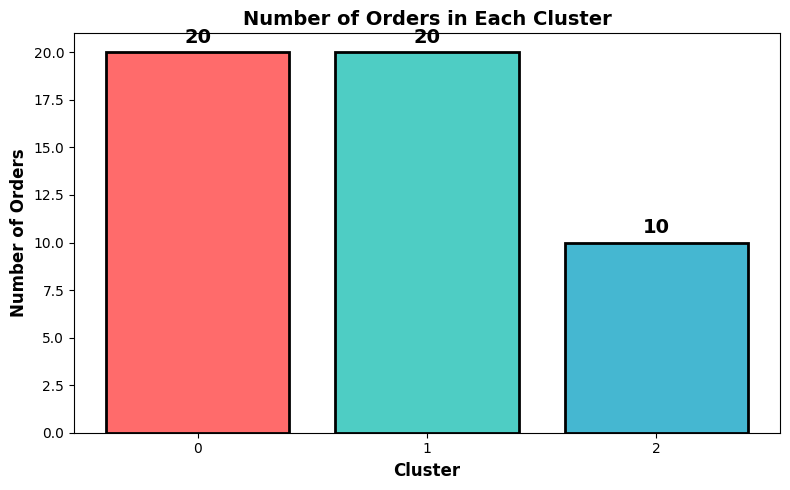

Bar chart created!


In [16]:
# Create a bar chart
plt.figure(figsize=(8, 5))

# Get cluster counts
counts = df['Cluster'].value_counts().sort_index()

# Create bar chart
bars = plt.bar(
    counts.index,
    counts.values,
    color=colors,
    edgecolor='black',
    linewidth=2
)

# Add count labels on top of each bar
for bar, count in zip(bars, counts.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        str(count),
        ha='center',
        fontsize=14,
        fontweight='bold'
    )

plt.xlabel('Cluster', fontsize=12, fontweight='bold')
plt.ylabel('Number of Orders', fontsize=12, fontweight='bold')
plt.title('Number of Orders in Each Cluster', fontsize=14, fontweight='bold')
plt.xticks([0, 1, 2])

plt.tight_layout()
plt.show()

print("Bar chart created!")

In [17]:
# Create a summary for each cluster
print("\n" + "=" * 70)
print("CUSTOMER SEGMENTATION REPORT")
print("=" * 70)
# Analyze each cluster
for cluster_num in sorted(df['Cluster'].unique()):
    # Get data for this cluster
    cluster_data = df[df['Cluster'] == cluster_num]

    # Calculate statistics
    avg_amount = cluster_data['Amount'].mean()
    count = len(cluster_data)

    # Assign business name based on spending
    if avg_amount <= 150:
        customer_type = "BUDGET CUSTOMERS"
        emoji = "💰"
        suggestion = "Offer discounts and deals to encourage bigger purchases"
    elif avg_amount <= 250:
        customer_type = "REGULAR CUSTOMERS"
        emoji = "🛒"
        suggestion = "Send loyalty rewards and personalized recommendations"
    else:
        customer_type = "PREMIUM CUSTOMERS"
        emoji = "⭐"
        suggestion = "Offer VIP treatment, exclusive products, and priority service"

    # Print the summary
    print(f"\n{emoji} CLUSTER {cluster_num}: {customer_type}")
    print("-" * 50)
    print(f"   Number of orders: {count}")
    print(f"   Average spending: ${avg_amount:.2f}")
    print(f"   Marketing tip: {suggestion}")



CUSTOMER SEGMENTATION REPORT

⭐ CLUSTER 0: PREMIUM CUSTOMERS
--------------------------------------------------
   Number of orders: 20
   Average spending: $375.00
   Marketing tip: Offer VIP treatment, exclusive products, and priority service

💰 CLUSTER 1: BUDGET CUSTOMERS
--------------------------------------------------
   Number of orders: 20
   Average spending: $125.00
   Marketing tip: Offer discounts and deals to encourage bigger purchases

🛒 CLUSTER 2: REGULAR CUSTOMERS
--------------------------------------------------
   Number of orders: 10
   Average spending: $200.00
   Marketing tip: Send loyalty rewards and personalized recommendations


In [18]:
# Show the final DataFrame
print("Final DataFrame with Clusters:")
print("=" * 50)
df.head(15)
# Save to a new CSV file (optional)
# Uncomment the line below if you want to save
# df.to_csv('clustered_orders.csv', index=False)

print("You can save the results by uncommenting the line above!")

Final DataFrame with Clusters:
You can save the results by uncommenting the line above!
